In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils as nn_utils

import torch.optim as optim
from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt

import os


In [15]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
DEVICE  = "cpu"
print(DEVICE)

CROP_CLASSES = ["No data", "Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
CROP_IDS = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8]



cpu


In [3]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True, show_plot=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(-1, 9)))} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(0, 9)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}   

    if show_plot:
        plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


In [4]:
def remap_labels_for_ce_loss(labels, ignore_index=-1):
    labels = labels.clone().detach()
    mask = (labels != ignore_index)
    labels[mask] -= 1
    return labels


In [5]:
#Load dataset
# agumented_data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/7_augumented_data_64X64_majority60.npy') 
# agumented_labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/8_augumented_labels_64X64_majority60.npy') 

# original_data = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/9_filtered_data_64X64_majority60.npy")
# original_labels = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/10_filtered_labels_64X64_majority60.npy")

data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/11_final_gan_data_without_mixed_patches_64X64_majority60.npy')
labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/12_final_gan_labels_without_mixed_patches_64X64_majority60.npy')

# Update labels to bring the labels in to ranging from 0 to 9
labels_upadated = remap_labels_for_ce_loss(torch.tensor(labels))
print(data.shape)
print(labels.shape)


(4403, 64, 64, 4)
(4403, 64, 64)


min_std = None
min_varience = None
index = None
extreme_diffs = None
extreme_diff_index = None
for i in range(1,1000):
    train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels, test_size=0.2, random_state=i)
    validation_data, test_data, validation_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=2)

    dict_percs = calculate_overall_class_distribution(train_labels, include_no_data= False, show_plot=False)
    values = dict_percs.values()

    std = statistics.variance(values)


    if i%100==0:
        print(i)

    if min_std == None:
        min_std = std
        index = i
    elif std<min_std:
        min_std = std
        index = i

    max_min_diff = max(values)- min(values)
    if extreme_diffs == None:
        extreme_diffs = max_min_diff
        extreme_diff_index = i
    elif max_min_diff<extreme_diffs:
        extreme_diffs = max_min_diff
        extreme_diff_index = i

print(index, min_std) 
print(extreme_diff_index, extreme_diffs)


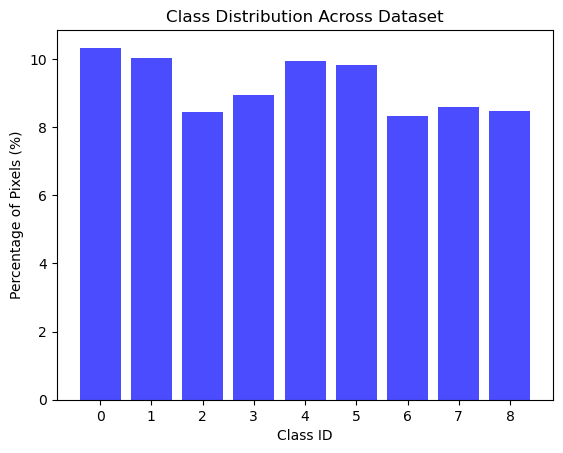

{0: 10.327349461864706,
 1: 10.028682710906445,
 2: 8.442940135221464,
 3: 8.950297904244747,
 4: 9.936606619995741,
 5: 9.824837073218342,
 6: 8.325035879383163,
 7: 8.602068249574106,
 8: 8.485127524311471}

In [6]:
seed_value = 636
train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels_upadated.cpu().numpy(), test_size=0.2, random_state=seed_value)
validation_data, test_data, validation_labels, test_labels = train_test_split(validation_test_data, validation_test_labels, test_size=0.5, random_state=seed_value)

calculate_overall_class_distribution(train_labels, include_no_data= False)


In [17]:
class ViTGenerator(nn.Module):
    def __init__(self, num_classes=10, patch_size=8, image_size=64, embed_dim=512, depth=6, heads=8, out_channels=4):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2 
        self.patch_dim = patch_size * patch_size * num_classes

        self.embed = nn.Linear(self.patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim, device=DEVICE))

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim*4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.to_patch = nn.Linear(embed_dim, patch_size * patch_size * out_channels)

    def forward(self, label_map):  # (N, 64, 64)
        N, H, W = label_map.shape

        label_mapping = label_map.clone().detach()
        label_mapping[label_mapping == -1] = 0  # Replace ignore index

        one_hot = F.one_hot(label_mapping, num_classes=10).permute(0, 3, 1, 2).float()  # (N, 10, H, W)

        # Patchify
        patches = one_hot.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(N, one_hot.shape[1], -1, self.patch_size, self.patch_size)
        patches = patches.permute(0, 2, 1, 3, 4).contiguous().view(N, self.num_patches, -1)  # (N, num_patches, patch_dim)

        x = self.embed(patches.to(self.pos_embed.dtype)) + self.pos_embed
        x = self.transformer(x)

        out = self.to_patch(x).view(N, self.num_patches, -1, self.patch_size, self.patch_size)
        out = out.permute(0, 2, 1, 3, 4).contiguous().view(N, 4, H, W)
        return torch.tanh(out)



In [8]:
def plot_losses(losses_g, losses_d, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(losses_g, label='Generator Loss')
    plt.plot(losses_d, label='Discriminator Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Generator and Discriminator Loss Over Time")
    if save_path:
        plt.savefig(save_path)
    plt.show()

# Save model function
def save_model(model, path):
    torch.save(model.state_dict(), path)


In [ ]:
# Hybrid Discriminator definition
class HybridTransformerDiscriminator(nn.Module):
    def __init__(self, in_channels=4, num_classes=10, embed_dim=256, patch_size=8, image_size=64):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * in_channels

        self.conv_stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU()
        )

        self.patch_embed = nn.Linear(self.patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=embed_dim*4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.disc_head = nn.Linear(embed_dim, 1)
        self.seg_head = nn.Conv2d(128, num_classes, kernel_size=1)

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(N, 4, H, W)
        N = x.size(0)

        # Convolutional feature extractor
        x = self.conv_stem(x)  # (N, 4, 64, 64) → maybe same shape if conv_blocks is identity or light conv

        # Patchify: (N, C=4, H=64, W=64) → (N, num_patches=64, patch_dim=256)
        patches = x.unfold(2, 8, 8).unfold(3, 8, 8)  # (N, C, 8, 8, 8, 8)
        patches = patches.contiguous().view(N, x.shape[1], -1, 8, 8)  # (N, 4, 64, 8, 8)
        patches = patches.permute(0, 2, 1, 3, 4).contiguous().view(N, -1, 4 * 8 * 8)  # (N, 64, 256)

        # Linear embedding + position
        tokens = self.patch_embed(patches)  # (N, 64, embed_dim)
        tokens = tokens + self.pos_embed  # (N, 64, embed_dim)

        # Add [CLS] token
        cls_token = self.class_token.expand(N, -1, -1)  # (N, 1, embed_dim)
        tokens = torch.cat((cls_token, tokens), dim=1)  # (N, 65, embed_dim)

        # Transformer
        tokens = self.transformer(tokens)  # (N, 65, embed_dim)

        # Classification token output → for GAN "real/fake"
        cls_out = self.mlp_head(tokens[:, 0])  # (N, 1)

        # Patch tokens → for segmentation
        patch_tokens = tokens[:, 1:]  # (N, 64, embed_dim)
        seg_out = self.segmentation_head(patch_tokens)  # (N, 64, num_classes)
        seg_out = seg_out.permute(0, 2, 1).contiguous().view(N, self.num_classes, 8, 8)  # (N, num_classes, 8, 8)

        return cls_out, seg_out



In [10]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [22]:
def train_acgan(generator, discriminator, dataloader, num_epochs=50, lr=1e-4, lambda_seg=1.0, device='cuda'):
    g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion_gan = nn.BCEWithLogitsLoss()
    criterion_seg = nn.CrossEntropyLoss(ignore_index=-1)

    generator.to(device)
    discriminator.to(device)

    losses_g, losses_d = [], []

    for epoch in range(num_epochs):
        g_loss_total, d_loss_total = 0, 0

        for real_images, labels in dataloader:
            real_images, labels = real_images.to(device), labels.to(device)
            N = real_images.size(0)
            valid = torch.ones(N, 1).to(device)
            fake = torch.zeros(N, 1).to(device)

            # ---------------------
            #  Train Generator
            # ---------------------
            g_optimizer.zero_grad()
            noise_labels = labels.clone().detach().long()
            fake_images = generator(noise_labels)

            pred_fake, seg_fake = discriminator(fake_images)
            g_gan_loss = criterion_gan(pred_fake, valid)
            g_seg_loss = criterion_seg(seg_fake, labels)
            g_loss = g_gan_loss + lambda_seg * g_seg_loss
            g_loss.backward()
            g_optimizer.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------
            d_optimizer.zero_grad()
            pred_real, seg_real = discriminator(real_images)
            pred_fake_detach, seg_fake_detach = discriminator(fake_images.detach())

            d_real_loss = criterion_gan(pred_real, valid)
            d_fake_loss = criterion_gan(pred_fake_detach, fake)
            d_seg_loss = criterion_seg(seg_real, labels)
            d_loss = d_real_loss + d_fake_loss + lambda_seg * d_seg_loss
            d_loss.backward()
            d_optimizer.step()

            g_loss_total += g_loss.item()
            d_loss_total += d_loss.item()

        avg_g = g_loss_total / len(dataloader)
        avg_d = d_loss_total / len(dataloader)
        losses_g.append(avg_g)
        losses_d.append(avg_d)

        print(f"Epoch [{epoch+1}/{num_epochs}]  G Loss: {avg_g:.4f}  D Loss: {avg_d:.4f}")

        # Save models
        if (epoch + 1) % 10 == 0:
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(generator.state_dict(), f"checkpoints/generator_epoch{epoch+1}.pth")
            torch.save(discriminator.state_dict(), f"checkpoints/discriminator_epoch{epoch+1}.pth")

    return losses_g, losses_d


In [25]:
generator = ViTGenerator(num_classes=10)
discriminator = HybridTransformerDiscriminator(in_channels=4, num_classes=10)
dataset = ImageLabelDataset(train_data, train_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
losses_g, losses_d = train_acgan(generator, discriminator, loader, device=DEVICE)
plot_losses(losses_g, losses_d)


RuntimeError: The size of tensor a (2048) must match the size of tensor b (64) at non-singleton dimension 1

In [ ]:
labels_clone = torch.from_numpy(train_labels).clone()  # to avoid modifying original tensor
labels_clone[labels_clone == -1] = -1  # keep ignore index as is
labels_clone[labels_clone != -1] = labels_clone[labels_clone != -1] - 1  # shift to zero-based index
